In [22]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

warnings.filterwarnings('ignore')


# Airbnb vs Traditional Hotels: A Comparative Analysis

## Project Overview
This analysis compares two major accommodation platforms to identify specific pricing strategies, 
booking behaviors, and market positioning differences.

## Data Sources
1. **Hotel Booking Demand Dataset**
   - Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
   
2. **Airbnb Open Data**
   - Source: https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata


### Dataset Overview

In [4]:
print("="*70)
print("LOADING DATASET 1: HOTEL BOOKINGS")
print("="*70)

df_hotel = pd.read_csv('data/hotel_bookings.csv')

print(f"\nDataset Shape: {df_hotel.shape}")
print(f"Rows: {df_hotel.shape[0]:,}")
print(f"Columns: {df_hotel.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(df_hotel.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*70)

LOADING DATASET 1: HOTEL BOOKINGS

Dataset Shape: (119390, 32)
Rows: 119,390
Columns: 32

Column Names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date



In [6]:
print("="*70)
print("LOADING DATASET 2: AIRBNB LISTINGS")
print("="*70)

df_airbnb = pd.read_csv('data/airbnb__data.csv')

print(f"\nDataset Shape: {df_airbnb.shape}")
print(f"Rows: {df_airbnb.shape[0]:,}")
print(f"Columns: {df_airbnb.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(df_airbnb.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*70)

LOADING DATASET 2: AIRBNB LISTINGS

Dataset Shape: (102599, 26)
Rows: 102,599
Columns: 26

Column Names:
1. id
2. NAME
3. host id
4. host_identity_verified
5. host name
6. neighbourhood group
7. neighbourhood
8. lat
9. long
10. country
11. country code
12. instant_bookable
13. cancellation_policy
14. room type
15. Construction year
16. price
17. service fee
18. minimum nights
19. number of reviews
20. last review
21. reviews per month
22. review rate number
23. calculated host listings count
24. availability 365
25. house_rules
26. license



In [7]:
print("="*70)
print("MISSING VALUES ANALYSIS - HOTELS")
print("="*70)

missing_hotel = df_hotel.isnull().sum()
missing_pct = (missing_hotel / len(df_hotel) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_hotel.index,
    'Missing_Count': missing_hotel.values,
    'Percentage': missing_pct.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with missing values:\n")
    print(missing_df.to_string(index=False))
else:
    print("\nNo missing values detected!")

MISSING VALUES ANALYSIS - HOTELS

Columns with missing values:

  Column  Missing_Count  Percentage
 company         112593       94.31
   agent          16340       13.69
 country            488        0.41
children              4        0.00


In [32]:
print("="*70)
print("MISSING VALUES ANALYSIS - AIRBNB")
print("="*70)

missing_airbnb = df_airbnb.isnull().sum()
missing_pct_ab = (missing_airbnb / len(df_airbnb) * 100).round(2)

missing_df_ab = pd.DataFrame({
    'Column': missing_airbnb.index,
    'Missing_Count': missing_airbnb.values,
    'Percentage': missing_pct_ab.values
})

missing_df_ab = missing_df_ab[missing_df_ab['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df_ab) > 0:
    print("\nTop 20 Columns with missing values:\n")
    print(missing_df_ab.head(20).to_string(index=False))
else:
    print("\nNo missing values detected!")

MISSING VALUES ANALYSIS - AIRBNB

Top 20 Columns with missing values:

                        Column  Missing_Count  Percentage
                   last review          15867       15.50
             reviews per month          15852       15.49
            country_normalized            527        0.51
                       country            527        0.51
              availability 365            448        0.44
                minimum nights            409        0.40
                     host name            401        0.39
            review rate number            326        0.32
calculated host listings count            319        0.31
        host_identity_verified            285        0.28
                          NAME            247        0.24
                   service fee            239        0.23
             Construction year            210        0.21
             number of reviews            183        0.18
                  country code            126        0.12
 

In [33]:
# Understanding Data Structure for Fair Comparison
print("="*70)
print("DATASET STRUCTURE ANALYSIS")
print("="*70)

print("\nHOTEL DATASET KEY COLUMNS:")
hotel_cols = df_hotel.columns.tolist()
print(f"Total columns: {len(hotel_cols)}")
print("\nRelevant columns for analysis:")
for col in hotel_cols:
    if any(keyword in col.lower() for keyword in ['country', 'adr', 'price', 'rate', 'guest', 'night', 'market', 'customer']):
        print(f"  - {col}")

print("\n" + "-"*70)

print("\nAIRBNB DATASET KEY COLUMNS:")
airbnb_cols = df_airbnb.columns.tolist()
print(f"Total columns: {len(airbnb_cols)}")
print("\nRelevant columns for analysis:")
for col in airbnb_cols[:20]:  # Show first 20 to avoid clutter
    print(f"  - {col}")

print("\n" + "="*70)

DATASET STRUCTURE ANALYSIS

HOTEL DATASET KEY COLUMNS:
Total columns: 32

Relevant columns for analysis:
  - stays_in_weekend_nights
  - stays_in_week_nights
  - country
  - market_segment
  - is_repeated_guest
  - customer_type
  - adr
  - country_normalized

----------------------------------------------------------------------

AIRBNB DATASET KEY COLUMNS:
Total columns: 25

Relevant columns for analysis:
  - id
  - NAME
  - host id
  - host_identity_verified
  - host name
  - neighbourhood group
  - neighbourhood
  - lat
  - long
  - country
  - country code
  - instant_bookable
  - cancellation_policy
  - room type
  - Construction year
  - price
  - service fee
  - minimum nights
  - number of reviews
  - last review



### FIND COMMON PATTERNS FOR COMPARATIVE ANALYSIS

#### Rating Analyses

In [40]:
# Find Rating Columns
print("="*70)
print("RATING COLUMN IDENTIFICATION")
print("="*70)

# Hotel ratings
hotel_rating_cols = [col for col in df_hotel.columns if any(keyword in col.lower() for keyword in ['rating', 'review', 'score', 'satisfaction'])]
print(f"\nHOTEL DATASET - Potential rating columns:")
if hotel_rating_cols:
    for col in hotel_rating_cols:
        print(f"  - {col}: {df_hotel[col].dtype}, non-null: {df_hotel[col].notna().sum():,}")
else:
    print("  No rating columns found")

# Airbnb ratings
airbnb_rating_cols = [col for col in df_airbnb.columns if any(keyword in col.lower() for keyword in ['rating', 'review', 'score', 'satisfaction'])]
print(f"\nAIRBNB DATASET - Potential rating columns:")
if airbnb_rating_cols:
    for col in airbnb_rating_cols[:10]:  # Limit output
        print(f"  - {col}: {df_airbnb[col].dtype}, non-null: {df_airbnb[col].notna().sum():,}")
else:
    print("  No rating columns found")

# Select best rating columns
hotel_rating = None
if hotel_rating_cols:
    # Prefer columns with most non-null values
    hotel_rating = max(hotel_rating_cols, key=lambda x: df_hotel[x].notna().sum())
    print(f"\nSelected HOTEL rating column: '{hotel_rating}'")
else:
    print("\nNo hotel rating column available")

airbnb_rating = None
rating_options = ['review_scores_rating', 'review scores rating', 'rating', 'Rating']
for col in rating_options:
    if col in df_airbnb.columns:
        airbnb_rating = col
        print(f"Selected AIRBNB rating column: '{col}'")
        break

if not airbnb_rating and airbnb_rating_cols:
    airbnb_rating = max(airbnb_rating_cols, key=lambda x: df_airbnb[x].notna().sum())
    print(f"Selected AIRBNB rating column: '{airbnb_rating}'")
elif not airbnb_rating:
    print("No Airbnb rating column available")

# Final conclusion
print("\n" + "="*70)
print("RATING COMPARISON FEASIBILITY")
print("="*70)

if hotel_rating and airbnb_rating:
    print("\nSTATUS: Rating comparison is POSSIBLE")
    print(f"  Hotel rating: '{hotel_rating}'")
    print(f"  Airbnb rating: '{airbnb_rating}'")
    print("\nWe can proceed with rating-based comparative analysis")
elif not hotel_rating and not airbnb_rating:
    print("\nSTATUS: Rating comparison is NOT POSSIBLE")
    print("REASON: Neither dataset contains rating columns")
    print("\nCONCLUSION:")
    print("Rating-based comparison cannot be performed with these datasets.")
    print("Alternative analyses available:")
    print("  - Price analysis (Airbnb)")
    print("  - Booking patterns (Hotels)")
    print("  - Geographic distribution")
    print("  - Temporal trends")
elif not hotel_rating:
    print("\nSTATUS: Rating comparison is NOT POSSIBLE")
    print("REASON: Hotel dataset lacks rating columns")
    print(f"  Airbnb has: '{airbnb_rating}'")
    print("\nCONCLUSION:")
    print("Cannot perform rating comparison as hotel ratings are unavailable.")
    print("Focus will remain on available metrics in each dataset independently.")
else:  # not airbnb_rating
    print("\nSTATUS: Rating comparison is NOT POSSIBLE")
    print("REASON: Airbnb dataset lacks rating columns")
    print(f"  Hotel has: '{hotel_rating}'")
    print("\nCONCLUSION:")
    print("Cannot perform rating comparison as Airbnb ratings are unavailable.")
    print("Analysis will focus on price patterns and booking behaviors separately.")

print("="*70)

RATING COLUMN IDENTIFICATION

HOTEL DATASET - Potential rating columns:
  No rating columns found

AIRBNB DATASET - Potential rating columns:
  - number of reviews: float64, non-null: 102,169
  - last review: object, non-null: 86,485
  - reviews per month: float64, non-null: 86,500
  - review rate number: float64, non-null: 102,026

No hotel rating column available
Selected AIRBNB rating column: 'number of reviews'

RATING COMPARISON FEASIBILITY

STATUS: Rating comparison is NOT POSSIBLE
REASON: Hotel dataset lacks rating columns
  Airbnb has: 'number of reviews'

CONCLUSION:
Cannot perform rating comparison as hotel ratings are unavailable.
Focus will remain on available metrics in each dataset independently.


#### Price Analyses in common geographical locations

In [43]:
# Find Common Geographic Locations
print("="*70)
print("GEOGRAPHIC ALIGNMENT ANALYSIS")
print("="*70)

# Check Hotel countries
if 'country' in df_hotel.columns:
    print("\nHOTEL DATASET - Top Countries:")
    hotel_countries = df_hotel['country'].value_counts().head(10)
    for country, count in hotel_countries.items():
        print(f"  {country}: {count:,} bookings")

# Check Airbnb locations
location_cols = ['country', 'Country', 'country_code', 'country code']
airbnb_country_col = None
for col in location_cols:
    if col in df_airbnb.columns:
        airbnb_country_col = col
        break

if airbnb_country_col:
    print(f"\nAIRBNB DATASET - Top Countries (column: '{airbnb_country_col}'):")
    airbnb_countries = df_airbnb[airbnb_country_col].value_counts().head(10)
    for country, count in airbnb_countries.items():
        print(f"  {country}: {count:,} listings")

# Find common countries (normalize variations like USA/US)
print("\n" + "-"*70)
print("\nFINDING COMMON LOCATIONS...")

# Country mapping dictionary
country_mapping = {
    'USA': ['USA', 'US', 'United States', 'United States of America'],
    'UK': ['UK', 'GB', 'GBR', 'United Kingdom', 'Great Britain'],
    'PRT': ['PRT', 'PT', 'Portugal'],
    'ESP': ['ESP', 'ES', 'Spain'],
    'FRA': ['FRA', 'FR', 'France'],
    'ITA': ['ITA', 'IT', 'Italy'],
    'DEU': ['DEU', 'DE', 'Germany'],
}

# Normalize hotel countries
if 'country' in df_hotel.columns:
    df_hotel['country_normalized'] = df_hotel['country']
    for standard, variations in country_mapping.items():
        df_hotel.loc[df_hotel['country'].isin(variations), 'country_normalized'] = standard

# Normalize airbnb countries
if airbnb_country_col:
    df_airbnb['country_normalized'] = df_airbnb[airbnb_country_col]
    for standard, variations in country_mapping.items():
        df_airbnb.loc[df_airbnb[airbnb_country_col].isin(variations), 'country_normalized'] = standard

# Find overlap
if 'country_normalized' in df_hotel.columns and 'country_normalized' in df_airbnb.columns:
    hotel_countries_norm = set(df_hotel['country_normalized'].dropna().unique())
    airbnb_countries_norm = set(df_airbnb['country_normalized'].dropna().unique())
    common_countries = hotel_countries_norm.intersection(airbnb_countries_norm)
    
    print(f"\nCommon countries found: {len(common_countries)}")
    for country in common_countries:
        hotel_count = (df_hotel['country_normalized'] == country).sum()
        airbnb_count = (df_airbnb['country_normalized'] == country).sum()
        print(f"  {country}: {hotel_count:,} hotel bookings | {airbnb_count:,} Airbnb listings")

GEOGRAPHIC ALIGNMENT ANALYSIS

HOTEL DATASET - Top Countries:
  PRT: 47,040 bookings
  GBR: 12,055 bookings
  FRA: 10,360 bookings
  ESP: 8,489 bookings
  DEU: 7,246 bookings
  ITA: 3,749 bookings
  IRL: 3,369 bookings
  BEL: 2,334 bookings
  BRA: 2,211 bookings
  NLD: 2,100 bookings

AIRBNB DATASET - Top Countries (column: 'country'):
  United States: 101,825 listings

----------------------------------------------------------------------

FINDING COMMON LOCATIONS...

Common countries found: 1
  USA: 2,086 hotel bookings | 101,825 Airbnb listings


In [44]:
# Step 1: Identify Price Columns
print("\nSTEP 1: IDENTIFY PRICE COLUMNS")
print("-"*70)

# Hotel price column (ADR = Average Daily Rate)
hotel_price_col = None
for col in df_hotel.columns:
    if 'adr' in col.lower():
        hotel_price_col = col
        break

if hotel_price_col:
    print(f"Hotel price column: '{hotel_price_col}' (Average Daily Rate)")
    print(f"  Non-null values: {df_hotel[hotel_price_col].notna().sum():,}")
    print(f"  Data type: {df_hotel[hotel_price_col].dtype}")
else:
    print("ERROR: No ADR column found in hotel dataset")

# Airbnb price column
airbnb_price_col = None
for col in df_airbnb.columns:
    if 'price' in col.lower():
        airbnb_price_col = col
        break

if airbnb_price_col:
    print(f"\nAirbnb price column: '{airbnb_price_col}'")
    print(f"  Non-null values: {df_airbnb[airbnb_price_col].notna().sum():,}")
    print(f"  Data type: {df_airbnb[airbnb_price_col].dtype}")
else:
    print("ERROR: No price column found in Airbnb dataset")


STEP 1: IDENTIFY PRICE COLUMNS
----------------------------------------------------------------------
Hotel price column: 'adr' (Average Daily Rate)
  Non-null values: 117,430
  Data type: float64

Airbnb price column: 'price'
  Non-null values: 102,352
  Data type: int64


In [45]:
# Step 2: Clean Price Data
print("\n" + "="*70)
print("STEP 2: CLEAN PRICE DATA")
print("-"*70)

# Clean Hotel ADR
if hotel_price_col:
    df_hotel_clean = df_hotel[df_hotel[hotel_price_col].notna()].copy()
    df_hotel_clean = df_hotel_clean[df_hotel_clean[hotel_price_col] > 0]
    
    print(f"\nHotel ADR after cleaning:")
    print(f"  Records: {len(df_hotel_clean):,}")
    print(f"  Mean: ${df_hotel_clean[hotel_price_col].mean():.2f}")
    print(f"  Median: ${df_hotel_clean[hotel_price_col].median():.2f}")
    print(f"  Range: ${df_hotel_clean[hotel_price_col].min():.2f} - ${df_hotel_clean[hotel_price_col].max():.2f}")

# Clean Airbnb Price
if airbnb_price_col:
    df_airbnb_clean = df_airbnb[df_airbnb[airbnb_price_col].notna()].copy()
    
    # Handle string prices if necessary
    if df_airbnb_clean[airbnb_price_col].dtype == 'object':
        print("\nCleaning Airbnb price format...")
        df_airbnb_clean[airbnb_price_col] = df_airbnb_clean[airbnb_price_col].astype(str).str.replace('$', '', regex=False)
        df_airbnb_clean[airbnb_price_col] = df_airbnb_clean[airbnb_price_col].str.replace(',', '', regex=False)
        df_airbnb_clean[airbnb_price_col] = df_airbnb_clean[airbnb_price_col].str.strip()
        df_airbnb_clean[airbnb_price_col] = pd.to_numeric(df_airbnb_clean[airbnb_price_col], errors='coerce')
        print("  Converted to numeric")
    
    df_airbnb_clean = df_airbnb_clean[df_airbnb_clean[airbnb_price_col] > 0]
    
    print(f"\nAirbnb Price after cleaning:")
    print(f"  Records: {len(df_airbnb_clean):,}")
    print(f"  Mean: ${df_airbnb_clean[airbnb_price_col].mean():.2f}")
    print(f"  Median: ${df_airbnb_clean[airbnb_price_col].median():.2f}")
    print(f"  Range: ${df_airbnb_clean[airbnb_price_col].min():.2f} - ${df_airbnb_clean[airbnb_price_col].max():.2f}")


STEP 2: CLEAN PRICE DATA
----------------------------------------------------------------------

Hotel ADR after cleaning:
  Records: 117,430
  Mean: $103.53
  Median: $95.00
  Range: $0.26 - $5400.00

Airbnb Price after cleaning:
  Records: 102,352
  Mean: $625.29
  Median: $624.00
  Range: $50.00 - $1200.00


In [46]:
# Step 3: Filter for USA
print("\n" + "="*70)
print("STEP 3: FILTER FOR USA (COMMON GEOGRAPHY)")
print("-"*70)

# Filter Hotels for USA
usa_hotel = None
if 'country' in df_hotel_clean.columns:
    usa_variations = ['USA', 'US', 'United States', 'United States of America']
    usa_hotel = df_hotel_clean[df_hotel_clean['country'].isin(usa_variations)].copy()
    
    if len(usa_hotel) == 0:
        print("\nNo USA records with standard names, checking all unique countries:")
        print(df_hotel_clean['country'].value_counts().head(10))
    else:
        print(f"\nHotel data (USA only):")
        print(f"  Records: {len(usa_hotel):,}")
        print(f"  Mean ADR: ${usa_hotel[hotel_price_col].mean():.2f}")
        print(f"  Median ADR: ${usa_hotel[hotel_price_col].median():.2f}")
else:
    print("\nWARNING: No 'country' column in hotel dataset")

# Filter Airbnb for USA
usa_airbnb = None
country_cols = ['country', 'Country', 'country_code', 'country code']
airbnb_country_col = None
for col in country_cols:
    if col in df_airbnb_clean.columns:
        airbnb_country_col = col
        break

if airbnb_country_col:
    usa_variations = ['USA', 'US', 'United States', 'United States of America']
    usa_airbnb = df_airbnb_clean[df_airbnb_clean[airbnb_country_col].isin(usa_variations)].copy()
    
    if len(usa_airbnb) == 0:
        print("\nNo USA records with standard names, checking all unique countries:")
        print(df_airbnb_clean[airbnb_country_col].value_counts().head(10))
    else:
        print(f"\nAirbnb data (USA only):")
        print(f"  Records: {len(usa_airbnb):,}")
        print(f"  Mean Price: ${usa_airbnb[airbnb_price_col].mean():.2f}")
        print(f"  Median Price: ${usa_airbnb[airbnb_price_col].median():.2f}")
else:
    print("\nWARNING: No country column in Airbnb dataset")

# Check if we have USA data
if usa_hotel is not None and len(usa_hotel) > 0 and usa_airbnb is not None and len(usa_airbnb) > 0:
    print("\n" + "-"*70)
    print("STATUS: USA data available for both datasets")
    print("Proceeding with USA-focused comparison")
elif usa_hotel is None or len(usa_hotel) == 0:
    print("\n" + "-"*70)
    print("WARNING: No USA data in hotel dataset")
    print("Will proceed with full datasets for comparison")
    usa_hotel = df_hotel_clean.copy()
elif usa_airbnb is None or len(usa_airbnb) == 0:
    print("\n" + "-"*70)
    print("WARNING: No USA data in Airbnb dataset")
    print("Will proceed with full datasets for comparison")
    usa_airbnb = df_airbnb_clean.copy()


STEP 3: FILTER FOR USA (COMMON GEOGRAPHY)
----------------------------------------------------------------------

Hotel data (USA only):
  Records: 2,086
  Mean ADR: $123.64
  Median ADR: $115.00

Airbnb data (USA only):
  Records: 101,825
  Mean Price: $625.38
  Median Price: $624.00

----------------------------------------------------------------------
STATUS: USA data available for both datasets
Proceeding with USA-focused comparison


In [47]:
# Step 4: Create Merged Price Comparison Dataset
print("\n" + "="*70)
print("STEP 4: CREATE MERGED PRICE DATASET")
print("-"*70)

# Create standardized hotel price data
hotel_price_df = pd.DataFrame({
    'platform': 'Hotel',
    'price': usa_hotel[hotel_price_col],
    'country': usa_hotel['country'] if 'country' in usa_hotel.columns else 'USA'
})

print(f"\nHotel price records: {len(hotel_price_df):,}")

# Create standardized Airbnb price data
airbnb_price_df = pd.DataFrame({
    'platform': 'Airbnb',
    'price': usa_airbnb[airbnb_price_col],
    'country': usa_airbnb[airbnb_country_col] if airbnb_country_col else 'USA'
})

print(f"Airbnb price records: {len(airbnb_price_df):,}")

# Merge datasets
merged_prices = pd.concat([hotel_price_df, airbnb_price_df], ignore_index=True)

print(f"\nMerged dataset:")
print(f"  Total records: {len(merged_prices):,}")
print(f"  Hotels: {len(merged_prices[merged_prices['platform'] == 'Hotel']):,}")
print(f"  Airbnb: {len(merged_prices[merged_prices['platform'] == 'Airbnb']):,}")

print("\nFirst few rows:")
print(merged_prices.head(10))

print("\nBasic statistics by platform:")
print(merged_prices.groupby('platform')['price'].describe())


STEP 4: CREATE MERGED PRICE DATASET
----------------------------------------------------------------------

Hotel price records: 2,086
Airbnb price records: 101,825

Merged dataset:
  Total records: 103,911
  Hotels: 2,086
  Airbnb: 101,825

First few rows:
  platform   price country
0    Hotel   97.00     USA
1    Hotel   98.00     USA
2    Hotel  153.00     USA
3    Hotel   94.71     USA
4    Hotel  117.81     USA
5    Hotel  117.81     USA
6    Hotel   87.30     USA
7    Hotel  150.00     USA
8    Hotel  131.00     USA
9    Hotel  110.00     USA

Basic statistics by platform:
             count        mean         std   min       25%    50%    75%  \
platform                                                                   
Airbnb    101825.0  625.382598  331.775075  50.0  339.0000  624.0  913.0   
Hotel       2086.0  123.640820   50.972201   2.0   88.6125  115.0  150.0   

              max  
platform           
Airbnb    1200.00  
Hotel      328.33  



STEP 5: PERCENTILE-BASED PRICE COMPARISON
----------------------------------------------------------------------

Why percentiles?
Hotels use ADR (per room), Airbnb shows total listing price
Percentiles allow fair comparison despite different metrics

----------------------------------------------------------------------
HOTEL PRICE PERCENTILES (ADR)
----------------------------------------------------------------------
10th percentile: $68.34
25th percentile: $88.61
50th percentile: $115.00
75th percentile: $150.00
90th percentile: $195.62
95th percentile: $223.00

----------------------------------------------------------------------
AIRBNB PRICE PERCENTILES
----------------------------------------------------------------------
10th percentile: $165.00
25th percentile: $339.00
50th percentile: $624.00
75th percentile: $913.00
90th percentile: $1086.00
95th percentile: $1143.00


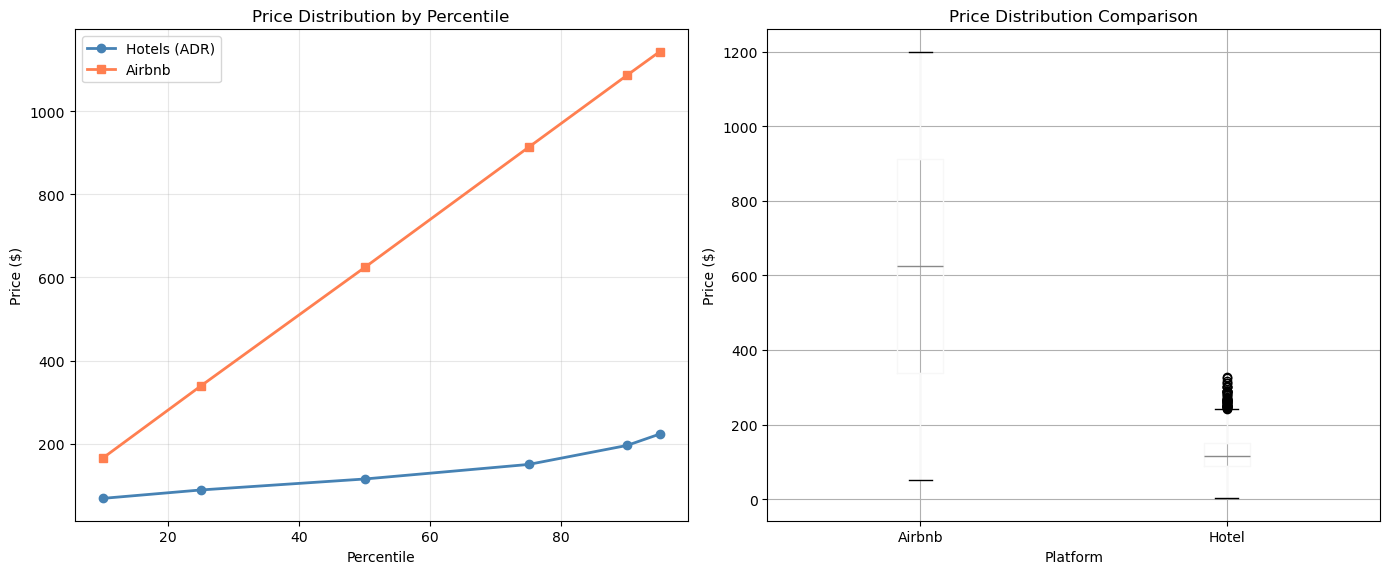


PRICE RATIO ANALYSIS (Airbnb/Hotel)
25th percentile: 3.83x (Airbnb is more expensive)
50th percentile: 5.43x (Airbnb is more expensive)
75th percentile: 6.09x (Airbnb is more expensive)


In [49]:
# Step 5: Percentile-Based Comparison
print("\n" + "="*70)
print("STEP 5: PERCENTILE-BASED PRICE COMPARISON")
print("-"*70)

print("\nWhy percentiles?")
print("Hotels use ADR (per room), Airbnb shows total listing price")
print("Percentiles allow fair comparison despite different metrics")

# Calculate percentiles for each platform
percentiles = [10, 25, 50, 75, 90, 95]

print("\n" + "-"*70)
print("HOTEL PRICE PERCENTILES (ADR)")
print("-"*70)
hotel_percentiles = {}
for p in percentiles:
    value = usa_hotel[hotel_price_col].quantile(p/100)
    hotel_percentiles[p] = value
    print(f"{p}th percentile: ${value:.2f}")

print("\n" + "-"*70)
print("AIRBNB PRICE PERCENTILES")
print("-"*70)
airbnb_percentiles = {}
for p in percentiles:
    value = usa_airbnb[airbnb_price_col].quantile(p/100)
    airbnb_percentiles[p] = value
    print(f"{p}th percentile: ${value:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Percentile comparison
axes[0].plot(percentiles, [hotel_percentiles[p] for p in percentiles], 
            marker='o', linewidth=2, label='Hotels (ADR)', color='steelblue')
axes[0].plot(percentiles, [airbnb_percentiles[p] for p in percentiles], 
            marker='s', linewidth=2, label='Airbnb', color='coral')
axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Distribution by Percentile')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
merged_prices.boxplot(column='price', by='platform', ax=axes[1])
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price Distribution Comparison')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

# Calculate price ratios at key percentiles
print("\n" + "="*70)
print("PRICE RATIO ANALYSIS (Airbnb/Hotel)")
print("="*70)
for p in [25, 50, 75]:
    ratio = airbnb_percentiles[p] / hotel_percentiles[p]
    print(f"{p}th percentile: {ratio:.2f}x (Airbnb is {'more' if ratio > 1 else 'less'} expensive)")



STEP 6: PRICE DISTRIBUTION ANALYSIS
----------------------------------------------------------------------


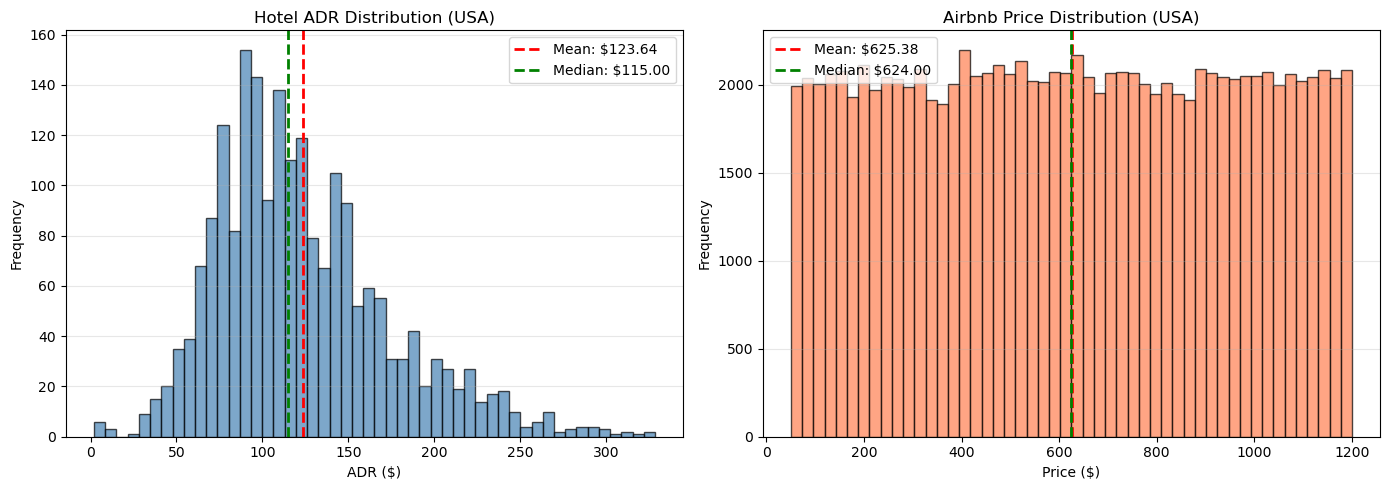


DISTRIBUTION CHARACTERISTICS:

Hotels:
  Skewness: 0.87
  Kurtosis: 0.81
  Coefficient of variation: 0.41

Airbnb:
  Skewness: 0.00
  Kurtosis: -1.19
  Coefficient of variation: 0.53


In [50]:
# Step 6: Detailed Price Distribution Analysis
print("\n" + "="*70)
print("STEP 6: PRICE DISTRIBUTION ANALYSIS")
print("-"*70)

# Side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hotel distribution
axes[0].hist(usa_hotel[hotel_price_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(usa_hotel[hotel_price_col].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: ${usa_hotel[hotel_price_col].mean():.2f}')
axes[0].axvline(usa_hotel[hotel_price_col].median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: ${usa_hotel[hotel_price_col].median():.2f}')
axes[0].set_xlabel('ADR ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Hotel ADR Distribution (USA)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Airbnb distribution
axes[1].hist(usa_airbnb[airbnb_price_col], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(usa_airbnb[airbnb_price_col].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: ${usa_airbnb[airbnb_price_col].mean():.2f}')
axes[1].axvline(usa_airbnb[airbnb_price_col].median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: ${usa_airbnb[airbnb_price_col].median():.2f}')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Airbnb Price Distribution (USA)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nDISTRIBUTION CHARACTERISTICS:")
print("\nHotels:")
print(f"  Skewness: {usa_hotel[hotel_price_col].skew():.2f}")
print(f"  Kurtosis: {usa_hotel[hotel_price_col].kurtosis():.2f}")
print(f"  Coefficient of variation: {(usa_hotel[hotel_price_col].std() / usa_hotel[hotel_price_col].mean()):.2f}")

print("\nAirbnb:")
print(f"  Skewness: {usa_airbnb[airbnb_price_col].skew():.2f}")
print(f"  Kurtosis: {usa_airbnb[airbnb_price_col].kurtosis():.2f}")
print(f"  Coefficient of variation: {(usa_airbnb[airbnb_price_col].std() / usa_airbnb[airbnb_price_col].mean()):.2f}")

In [54]:
# Step 7: Price Analysis Conclusions
print("\n" + "="*70)
print("PRICE ANALYSIS - KEY FINDINGS")
print("="*70)

print("\n1. DATASET SCOPE:")
print(f"   Hotels (USA): {len(usa_hotel):,} bookings analyzed")
print(f"   Airbnb (USA): {len(usa_airbnb):,} listings analyzed")

print("\n2. PRICE DISTRIBUTION CHARACTERISTICS:")

# Calculate spread metrics
hotel_iqr = hotel_percentiles[75] - hotel_percentiles[25]
airbnb_iqr = airbnb_percentiles[75] - airbnb_percentiles[25]

hotel_range_90 = hotel_percentiles[90] - hotel_percentiles[10]
airbnb_range_90 = airbnb_percentiles[90] - airbnb_percentiles[10]

print(f"\n   Interquartile Range (25th-75th percentile):")
print(f"   - Hotels: ${hotel_iqr:.2f} spread")
print(f"   - Airbnb: ${airbnb_iqr:.2f} spread")
print(f"   - Airbnb IQR is {airbnb_iqr/hotel_iqr:.2f}x wider than hotels")

print(f"\n   90th Percentile Range (10th-90th percentile):")
print(f"   - Hotels: ${hotel_range_90:.2f} spread")
print(f"   - Airbnb: ${airbnb_range_90:.2f} spread")
print(f"   - Ratio: {airbnb_range_90/hotel_range_90:.2f}x")

print("\n3. PRICE VARIABILITY (Coefficient of Variation):")
hotel_cv = usa_hotel[hotel_price_col].std() / usa_hotel[hotel_price_col].mean()
airbnb_cv = usa_airbnb[airbnb_price_col].std() / usa_airbnb[airbnb_price_col].mean()

print(f"   - Hotels: {hotel_cv:.2f} ({hotel_cv*100:.1f}% variation relative to mean)")
print(f"   - Airbnb: {airbnb_cv:.2f} ({airbnb_cv*100:.1f}% variation relative to mean)")

if airbnb_cv > hotel_cv * 1.2:
    print(f"\n   INTERPRETATION: Airbnb shows {((airbnb_cv/hotel_cv - 1)*100):.0f}% more price variability")
    print(f"   Reason: Diverse property types (shared rooms to luxury villas)")
elif hotel_cv > airbnb_cv * 1.2:
    print(f"\n   INTERPRETATION: Hotels show {((hotel_cv/airbnb_cv - 1)*100):.0f}% more price variability")
    print(f"   Reason: Wide range from budget to luxury hotels")
else:
    print(f"\n   INTERPRETATION: Similar price variability across platforms")

print("\n4. PERCENTILE DISTRIBUTION ANALYSIS:")
print("\n   Price growth across percentiles:")
print(f"   Hotels (25th to 75th): {((hotel_percentiles[75]/hotel_percentiles[25] - 1)*100):.1f}% increase")
print(f"   Airbnb (25th to 75th): {((airbnb_percentiles[75]/airbnb_percentiles[25] - 1)*100):.1f}% increase")

print(f"\n   Price growth to top tier:")
print(f"   Hotels (50th to 90th): {((hotel_percentiles[90]/hotel_percentiles[50] - 1)*100):.1f}% increase")
print(f"   Airbnb (50th to 90th): {((airbnb_percentiles[90]/airbnb_percentiles[50] - 1)*100):.1f}% increase")

# Identify which platform has steeper premium tier
hotel_premium_jump = hotel_percentiles[90] / hotel_percentiles[50]
airbnb_premium_jump = airbnb_percentiles[90] / airbnb_percentiles[50]

if airbnb_premium_jump > hotel_premium_jump * 1.1:
    print(f"\n   PATTERN: Airbnb premium tier commands significantly higher premiums")
    print(f"   Top 10% of Airbnb listings are {airbnb_premium_jump:.1f}x median price")
elif hotel_premium_jump > airbnb_premium_jump * 1.1:
    print(f"\n   PATTERN: Hotel premium tier shows steeper pricing")
    print(f"   Top 10% of hotels are {hotel_premium_jump:.1f}x median ADR")
else:
    print(f"\n   PATTERN: Both platforms show similar premium tier pricing structure")

print("\n5. MARKET STRUCTURE INSIGHTS:")

# Calculate concentration in different price tiers
# Calculate 33rd and 67th percentiles for tier analysis
hotel_p33 = usa_hotel[hotel_price_col].quantile(0.33)
hotel_p67 = usa_hotel[hotel_price_col].quantile(0.67)

airbnb_p33 = usa_airbnb[airbnb_price_col].quantile(0.33)
airbnb_p67 = usa_airbnb[airbnb_price_col].quantile(0.67)

# Calculate concentration in different price tiers
hotel_budget = (usa_hotel[hotel_price_col] < hotel_p33).sum()
hotel_mid = ((usa_hotel[hotel_price_col] >= hotel_p33) & 
             (usa_hotel[hotel_price_col] < hotel_p67)).sum()
hotel_premium = (usa_hotel[hotel_price_col] >= hotel_p67).sum()

airbnb_budget = (usa_airbnb[airbnb_price_col] < airbnb_p33).sum()
airbnb_mid = ((usa_airbnb[airbnb_price_col] >= airbnb_p33) & 
              (usa_airbnb[airbnb_price_col] < airbnb_p67)).sum()
airbnb_premium = (usa_airbnb[airbnb_price_col] >= airbnb_p67).sum()
print(f"\n   Hotels - Market segmentation:")
print(f"   - Budget tier (bottom 33%): {hotel_budget/len(usa_hotel)*100:.1f}%")
print(f"   - Mid-range (middle 33%): {hotel_mid/len(usa_hotel)*100:.1f}%")
print(f"   - Premium (top 33%): {hotel_premium/len(usa_hotel)*100:.1f}%")

print(f"\n   Airbnb - Market segmentation:")
print(f"   - Budget tier (bottom 33%): {airbnb_budget/len(usa_airbnb)*100:.1f}%")
print(f"   - Mid-range (middle 33%): {airbnb_mid/len(usa_airbnb)*100:.1f}%")
print(f"   - Premium (top 33%): {airbnb_premium/len(usa_airbnb)*100:.1f}%")

print("\n6. KEY TAKEAWAY:")
print("\n   NOTE: Direct price comparison is not meaningful due to different metrics:")
print(f"   - Hotels: ADR (Average Daily Rate per room)")
print(f"   - Airbnb: Total listing price (varies by property type)")
print(f"\n   FOCUS: Distribution patterns reveal market structure differences")

if airbnb_cv > hotel_cv * 1.3:
    print(f"\n   CONCLUSION: Airbnb market is more heterogeneous with wider price ranges")
    print(f"   reflecting diverse accommodation types from shared rooms to luxury homes.")
elif hotel_cv > airbnb_cv * 1.3:
    print(f"\n   CONCLUSION: Hotel market shows greater stratification")
    print(f"   with distinct budget/mid-range/luxury segments.")
else:
    print(f"\n   CONCLUSION: Both markets show similar price distribution patterns")
    print(f"   indicating comparable market segmentation strategies.")




PRICE ANALYSIS - KEY FINDINGS

1. DATASET SCOPE:
   Hotels (USA): 2,086 bookings analyzed
   Airbnb (USA): 101,825 listings analyzed

2. PRICE DISTRIBUTION CHARACTERISTICS:

   Interquartile Range (25th-75th percentile):
   - Hotels: $61.39 spread
   - Airbnb: $574.00 spread
   - Airbnb IQR is 9.35x wider than hotels

   90th Percentile Range (10th-90th percentile):
   - Hotels: $127.29 spread
   - Airbnb: $921.00 spread
   - Ratio: 7.24x

3. PRICE VARIABILITY (Coefficient of Variation):
   - Hotels: 0.41 (41.2% variation relative to mean)
   - Airbnb: 0.53 (53.1% variation relative to mean)

   INTERPRETATION: Airbnb shows 29% more price variability
   Reason: Diverse property types (shared rooms to luxury villas)

4. PERCENTILE DISTRIBUTION ANALYSIS:

   Price growth across percentiles:
   Hotels (25th to 75th): 69.3% increase
   Airbnb (25th to 75th): 169.3% increase

   Price growth to top tier:
   Hotels (50th to 90th): 70.1% increase
   Airbnb (50th to 90th): 74.0% increase

   

### HYPOTHESIS TESTING

####  Hypothesis Test 1 - Cancellation by Hotel Type


HYPOTHESIS TEST 1: CANCELLATION RATES BY HOTEL TYPE

RESEARCH QUESTION:
Do City Hotels and Resort Hotels have different cancellation rates?

----------------------------------------------------------------------
HYPOTHESES:
----------------------------------------------------------------------
H0 (Null): Cancellation rates are the same for both hotel types
H1 (Alternative): Cancellation rates differ between hotel types

----------------------------------------------------------------------
TEST SELECTION:
----------------------------------------------------------------------
Chi-squared test of independence
Reason: We're testing association between two categorical variables
  - Variable 1: Hotel type (City vs Resort)
  - Variable 2: Cancellation status (Canceled vs Not Canceled)

----------------------------------------------------------------------
DATA PREPARATION:
----------------------------------------------------------------------

Contingency Table:
              Not Canceled  

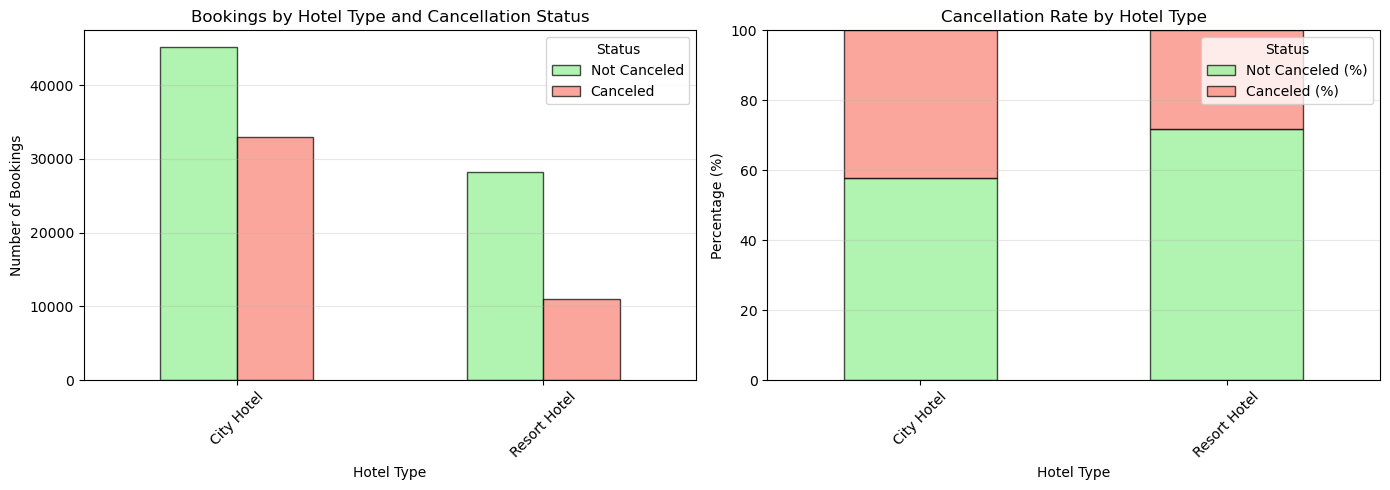


----------------------------------------------------------------------
PERFORMING CHI-SQUARED TEST:
----------------------------------------------------------------------

Test Statistics:
  Chi-squared statistic: 2226.3870
  Degrees of freedom: 1
  P-value: 0.000000
  Significance level: α = 0.05

Expected Frequencies (under null hypothesis):
              Not Canceled  Canceled
hotel                               
City Hotel        48843.05  29278.95
Resort Hotel      24575.95  14732.05

----------------------------------------------------------------------
DECISION:
----------------------------------------------------------------------
P-value (0.000000) < 0.05
REJECT the null hypothesis

Conclusion: There IS a statistically significant difference
in cancellation rates between City and Resort hotels.

----------------------------------------------------------------------
PRACTICAL INTERPRETATION:
----------------------------------------------------------------------

City Hotel:
  

In [55]:
# ----------------------------------------------------------------------------
# HYPOTHESIS TEST 1: CANCELLATION RATES BY HOTEL TYPE
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("HYPOTHESIS TEST 1: CANCELLATION RATES BY HOTEL TYPE")
print("="*70)

# Check if we have the necessary columns
if 'is_canceled' in df_hotel.columns and 'hotel' in df_hotel.columns:
    
    print("\nRESEARCH QUESTION:")
    print("Do City Hotels and Resort Hotels have different cancellation rates?")
    
    print("\n" + "-"*70)
    print("HYPOTHESES:")
    print("-"*70)
    print("H0 (Null): Cancellation rates are the same for both hotel types")
    print("H1 (Alternative): Cancellation rates differ between hotel types")
    
    print("\n" + "-"*70)
    print("TEST SELECTION:")
    print("-"*70)
    print("Chi-squared test of independence")
    print("Reason: We're testing association between two categorical variables")
    print("  - Variable 1: Hotel type (City vs Resort)")
    print("  - Variable 2: Cancellation status (Canceled vs Not Canceled)")
    
    print("\n" + "-"*70)
    print("DATA PREPARATION:")
    print("-"*70)
    
    # Create contingency table
    contingency_table = pd.crosstab(df_hotel['hotel'], df_hotel['is_canceled'])
    contingency_table.columns = ['Not Canceled', 'Canceled']
    
    print("\nContingency Table:")
    print(contingency_table)
    
    # Calculate percentages
    contingency_pct = pd.crosstab(df_hotel['hotel'], df_hotel['is_canceled'], normalize='index') * 100
    contingency_pct.columns = ['Not Canceled (%)', 'Canceled (%)']
    
    print("\nPercentage by Hotel Type:")
    print(contingency_pct.round(2))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Counts
    contingency_table.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'], 
                          edgecolor='black', alpha=0.7)
    axes[0].set_ylabel('Number of Bookings')
    axes[0].set_title('Bookings by Hotel Type and Cancellation Status')
    axes[0].set_xlabel('Hotel Type')
    axes[0].legend(title='Status')
    axes[0].grid(axis='y', alpha=0.3)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    
    # Percentages
    contingency_pct.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'],
                        edgecolor='black', alpha=0.7, stacked=True)
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_title('Cancellation Rate by Hotel Type')
    axes[1].set_xlabel('Hotel Type')
    axes[1].legend(title='Status')
    axes[1].set_ylim(0, 100)
    axes[1].grid(axis='y', alpha=0.3)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "-"*70)
    print("PERFORMING CHI-SQUARED TEST:")
    print("-"*70)
    
    # Perform chi-squared test
    from scipy.stats import chi2_contingency
    
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    print(f"\nTest Statistics:")
    print(f"  Chi-squared statistic: {chi2:.4f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Significance level: α = 0.05")
    
    print(f"\nExpected Frequencies (under null hypothesis):")
    expected_df = pd.DataFrame(expected_freq, 
                              index=contingency_table.index,
                              columns=contingency_table.columns)
    print(expected_df.round(2))
    
    print("\n" + "-"*70)
    print("DECISION:")
    print("-"*70)
    
    if p_value < 0.05:
        print(f"P-value ({p_value:.6f}) < 0.05")
        print("REJECT the null hypothesis")
        print("\nConclusion: There IS a statistically significant difference")
        print("in cancellation rates between City and Resort hotels.")
    else:
        print(f"P-value ({p_value:.6f}) >= 0.05")
        print("FAIL TO REJECT the null hypothesis")
        print("\nConclusion: There is NO statistically significant difference")
        print("in cancellation rates between hotel types.")
    
    print("\n" + "-"*70)
    print("PRACTICAL INTERPRETATION:")
    print("-"*70)
    
    # Calculate actual cancellation rates
    cancel_rates = df_hotel.groupby('hotel')['is_canceled'].mean() * 100
    
    for hotel_type in cancel_rates.index:
        rate = cancel_rates[hotel_type]
        count_canceled = contingency_table.loc[hotel_type, 'Canceled']
        count_total = contingency_table.loc[hotel_type].sum()
        print(f"\n{hotel_type}:")
        print(f"  Cancellation rate: {rate:.2f}%")
        print(f"  Canceled bookings: {count_canceled:,} out of {count_total:,}")
    
    # Calculate difference
    if len(cancel_rates) == 2:
        hotel_types = list(cancel_rates.index)
        rate_diff = abs(cancel_rates[hotel_types[0]] - cancel_rates[hotel_types[1]])
        higher_hotel = hotel_types[0] if cancel_rates[hotel_types[0]] > cancel_rates[hotel_types[1]] else hotel_types[1]
        
        print(f"\nDifference: {rate_diff:.2f} percentage points")
        print(f"{higher_hotel} have higher cancellation rates")
        
        if p_value < 0.05:
            print("\nPRACTICAL SIGNIFICANCE:")
            if rate_diff > 10:
                print(f"The {rate_diff:.1f}% difference is substantial and statistically significant.")
                print(f"Hotel management should consider different cancellation policies")
                print(f"or customer retention strategies for {higher_hotel}.")
            elif rate_diff > 5:
                print(f"The {rate_diff:.1f}% difference is moderate but statistically significant.")
                print(f"This suggests meaningful behavioral differences between customer segments.")
            else:
                print(f"While statistically significant, the {rate_diff:.1f}% difference is small.")
                print(f"Large sample size can detect small effects. Practical impact may be limited.")
    
    print("\n" + "="*70)
    print("HYPOTHESIS TEST 1 COMPLETE")
    print("="*70)
    
else:
    print("\nERROR: Required columns not found in dataset")
    print("Cannot perform cancellation analysis")
    if 'is_canceled' not in df_hotel.columns:
        print("  Missing: 'is_canceled' column")
    if 'hotel' not in df_hotel.columns:
        print("  Missing: 'hotel' column")